# Flood analysis by district: does the topological signature generalize?
Made by: Giovanni Guarnieri Soares

The pooled analysis (`Flood_analysis_statistics_OSM.ipynb`) found that flooded streets occupy more
central positions in the network. This notebook asks whether that signature **generalizes across
São Paulo**, using two complementary designs:

- **Design 1 — stratified central area**: the existing central-area network (`edges_centrals.csv`,
  metrics computed on the whole central graph) split by district, with a within-district test per
  district and a fixed-effects heterogeneity test.
- **Design 2 — one network per district, city-wide**: an independent street graph for every São
  Paulo district with ≥5 flood events in 2019; metrics computed *within* each district's own graph;
  per-district tests pooled by random-effects meta-analysis.

Comparing the designs is itself informative: Design 1 metrics see the whole central network as
context, Design 2 metrics only see the district. Agreement means the signature is robust to that
modeling choice.

Subgraph centrality is excluded here (its dense matrix exponential is infeasible for the largest
district graphs). Eigenvector centrality is excluded as well: it localizes on the densest cluster
of the line graph (medians are zero in both flood groups), its ranking is unstable to the buffer
choice, and it carries no signal after elevation adjustment in the pooled analysis. The five
metrics are degree, mean shortest path length, closeness, betweenness, and PageRank.

Outputs: tables in `results/`, per-district edge data in `results/districts/`, figures in `figures/`.

In [1]:
import os
import glob
import time
import unicodedata
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
from shapely import wkt

from scipy.stats import mannwhitneyu, spearmanr, chi2
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

ox.settings.use_cache = True
ox.settings.cache_folder = "cache"
CRS_METRIC = "EPSG:31983"  # SIRGAS 2000 / UTM 23S
FIGDIR = "figures"; os.makedirs(FIGDIR, exist_ok=True)
RESDIR = "results"; os.makedirs(f"{RESDIR}/districts", exist_ok=True)

METRICS = ["Degree", "Mean Shortest Path Length", "Closeness", "bet", "Pagerank"]
LABELS = {"Degree": "Degree", "Mean Shortest Path Length": "Mean shortest path length",
          "Closeness": "Closeness", "bet": "Betweenness", "Pagerank": "PageRank"}
MIN_FLOODED_EDGES = 5  # minimum flooded streets in a district to run a within-district test

floods = pd.read_csv("floods.csv", sep=";")
flood_pts = gpd.GeoDataFrame(floods, geometry=gpd.points_from_xy(floods["LONG"], floods["LAT"]),
                             crs="EPSG:4326").to_crs(CRS_METRIC)

districts_sp = gpd.read_file("Shapes/DI2010_RMSP_CEM.shp")
districts_sp = districts_sp[districts_sp["NOM_MU"] == "SAO PAULO"].to_crs(CRS_METRIC)
districts_sp["geometry"] = districts_sp.geometry.buffer(0)  # heal any invalid rings

ev_join = gpd.sjoin(flood_pts, districts_sp[["NOME", "geometry"]], how="left", predicate="within")
events_per_district = ev_join["NOME"].value_counts()
print(f"{len(districts_sp)} districts in Sao Paulo municipality; "
      f"{ev_join['NOME'].notna().sum()} of {len(flood_pts)} flood events fall inside one of them")

96 districts in Sao Paulo municipality; 1165 of 1165 flood events fall inside one of them


In [2]:
def slug(name):
    s = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode()
    return s.replace(" ", "_").replace("/", "-")

def mwu_effect(fl, nf):
    """Two-sided MWU p-value + rank-biserial correlation with a 95% CI
    (normal approximation on U). r > 0 means flooded streets have HIGHER values."""
    n1, n2 = len(fl), len(nf)
    U, p = mannwhitneyu(fl, nf, alternative="two-sided")
    r = 2 * U / (n1 * n2) - 1
    se_r = 2 * np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12.0) / (n1 * n2)
    return p, r, r - 1.96 * se_r, r + 1.96 * se_r, se_r

def district_tests(df, district, design):
    """Per-metric MWU + effect size for one district's edge table (needs flood_count column)."""
    fl = df[df["flood_count"] > 0]
    nf = df[df["flood_count"] == 0]
    rows = []
    for m in METRICS:
        a, b = fl[m].dropna(), nf[m].dropna()
        if len(a) < MIN_FLOODED_EDGES or len(b) < MIN_FLOODED_EDGES:
            continue
        p, r, lo, hi, se = mwu_effect(a, b)
        rows.append({"design": design, "district": district, "metric": LABELS[m],
                     "n_edges": len(df), "n_flooded": len(fl), "p_MWU": p,
                     "rank_biserial": r, "CI_low": lo, "CI_high": hi, "se": se})
    return rows

def compute_metrics(G):
    """Line-graph (street-level) metrics, written back as edge attributes of G.
    Mean shortest path and closeness come from a single all-pairs BFS pass."""
    H = nx.line_graph(G, nx.Graph)
    N = H.number_of_nodes()
    msp, clo = {}, {}
    for src, lengths in nx.all_pairs_shortest_path_length(H):
        s = sum(lengths.values()); k = len(lengths)
        msp[src] = s / k
        clo[src] = ((k - 1) / s) * ((k - 1) / (N - 1)) if s > 0 else 0.0
    nx.set_edge_attributes(G, msp, "Mean Shortest Path Length")
    nx.set_edge_attributes(G, clo, "Closeness")
    nx.set_edge_attributes(G, nx.edge_betweenness_centrality(G, weight="length"), "bet")
    nx.set_edge_attributes(G, dict(H.degree()), "Degree")
    nx.set_edge_attributes(G, nx.pagerank(H), "Pagerank")
    return G

def process_district(name, poly_metric, buffer_m):
    """Build the district's own street graph (polygon buffered by buffer_m meters),
    compute metrics, match the district's flood events (50 m, in meters), and return
    the edge table restricted to edges whose midpoint lies inside the UNBUFFERED polygon."""
    poly_wgs = gpd.GeoSeries([poly_metric.buffer(buffer_m)], crs=CRS_METRIC).to_crs("EPSG:4326").iloc[0]
    G = ox.convert.to_undirected(ox.graph_from_polygon(poly_wgs, network_type="drive"))
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    G = compute_metrics(G)

    pts = flood_pts[flood_pts.within(poly_metric)]
    fc = dict.fromkeys(G.edges, 0)
    if len(pts):
        G_proj = ox.projection.project_graph(G, to_crs=CRS_METRIC)
        ne, dist = ox.distance.nearest_edges(G_proj, pts.geometry.x, pts.geometry.y, return_dist=True)
        for e, d in zip(ne, dist):
            if d < 50:
                fc[e] += 1
    nx.set_edge_attributes(G, fc, "flood_count")

    _, edges = ox.graph_to_gdfs(G)
    edges = edges.reset_index()
    mid = edges.geometry.to_crs(CRS_METRIC).interpolate(0.5, normalized=True)
    edges = edges[mid.within(poly_metric).values]
    out = pd.DataFrame(edges[["u", "v", "key", "length", "flood_count"] + METRICS])
    out["district"] = name
    return out

## 1. Design 1 — stratify the existing central-area network by district

Metrics come from `edges_centrals.csv` and were computed on the **whole central graph**; here each
edge is assigned to a district by its midpoint and the flooded vs non-flooded test runs within each
district that has at least 5 flooded streets.

In [3]:
central = pd.read_csv("edges_centrals.csv")
central["geometry"] = central["geometry"].apply(wkt.loads)
central = gpd.GeoDataFrame(central, geometry="geometry", crs="EPSG:4326").to_crs(CRS_METRIC)

mid = gpd.GeoDataFrame(geometry=central.geometry.interpolate(0.5, normalized=True), crs=CRS_METRIC)
j = gpd.sjoin(mid, districts_sp[["NOME", "geometry"]], how="left", predicate="within")
j = j[~j.index.duplicated()]
central["district"] = j["NOME"].fillna("OUTSIDE").values

d1_rows = []
for name, df in central.groupby("district"):
    if name == "OUTSIDE":
        continue
    d1_rows += district_tests(df, name, "design1")
design1 = pd.DataFrame(d1_rows)
design1["p_BH"] = multipletests(design1["p_MWU"], method="fdr_bh")[1]
design1.to_csv(f"{RESDIR}/design1_district_tests.csv", index=False)
print(f"Design 1: {design1['district'].nunique()} districts testable "
      f"(of {central[central['district'] != 'OUTSIDE']['district'].nunique()} touched by the central network)")
design1[design1["metric"] == "Closeness"].sort_values("rank_biserial", ascending=False).round(4)

Design 1: 9 districts testable (of 21 touched by the central network)
Out[1]: 
     design       district     metric  n_edges  ...  CI_low  CI_high      se    p_BH
22  design1      LIBERDADE  Closeness      576  ...  0.3428   1.3602  0.2596  0.0128
17  design1        CAMBUCI  Closeness      691  ...  0.3070   1.2356  0.2369  0.0128
7   design1     BELA VISTA  Closeness      445  ... -0.2659   0.5973  0.2202  0.6571
42  design1             SE  Closeness      484  ... -0.0718   0.3850  0.1165  0.4243
12  design1     BOM RETIRO  Closeness      672  ... -0.2448   0.2823  0.1345  0.9529
27  design1      REPUBLICA  Closeness      617  ... -0.2361   0.2452  0.1228  0.9710
37  design1        SANTANA  Closeness      261  ... -0.5471   0.1515  0.1782  0.4821
32  design1  SANTA CECILIA  Closeness      619  ... -0.5101   0.0469  0.1421  0.3321
2   design1    BARRA FUNDA  Closeness      280  ... -0.8506  -0.0373  0.2075  0.1831

[9 rows x 11 columns]


     design       district     metric  n_edges  ...  CI_low  CI_high      se    p_BH
22  design1      LIBERDADE  Closeness      576  ...  0.3428   1.3602  0.2596  0.0128
17  design1        CAMBUCI  Closeness      691  ...  0.3070   1.2356  0.2369  0.0128
7   design1     BELA VISTA  Closeness      445  ... -0.2659   0.5973  0.2202  0.6571
42  design1             SE  Closeness      484  ... -0.0718   0.3850  0.1165  0.4243
12  design1     BOM RETIRO  Closeness      672  ... -0.2448   0.2823  0.1345  0.9529
27  design1      REPUBLICA  Closeness      617  ... -0.2361   0.2452  0.1228  0.9710
37  design1        SANTANA  Closeness      261  ... -0.5471   0.1515  0.1782  0.4821
32  design1  SANTA CECILIA  Closeness      619  ... -0.5101   0.0469  0.1421  0.3321
2   design1    BARRA FUNDA  Closeness      280  ... -0.8506  -0.0373  0.2075  0.1831

[9 rows x 11 columns]

In [4]:
# Formal heterogeneity test: does the closeness effect differ across districts?
# District fixed effects + likelihood-ratio test of the closeness x district interaction.
# Restricted to districts with >= 3 flooded edges (perfect-separation guard for the dummies).
ok_districts = central.groupby("district").apply(lambda d: (d["flood_count"] > 0).sum() >= 3)
reg = central[central["district"].isin(ok_districts[ok_districts].index)].copy()

def z(s):
    return (s - s.mean()) / s.std()

reg_df = pd.DataFrame({
    "flooded": (reg["flood_count"] > 0).astype(int),
    "closeness_z": z(reg["Closeness"]),
    "elevation_z": z(reg["elevation"]),
    "grade_abs_z": z(reg["grade_abs"]),
    "log_length_z": z(np.log(reg["length"])),
    "lanes_z": z(reg["lanes"]),
    "district": reg["district"].values,
})
import statsmodels.formula.api as smf
base = smf.logit("flooded ~ closeness_z + elevation_z + grade_abs_z + log_length_z + lanes_z + C(district)",
                 reg_df).fit(disp=0, maxiter=500)
inter = smf.logit("flooded ~ closeness_z * C(district) + elevation_z + grade_abs_z + log_length_z + lanes_z",
                  reg_df).fit(disp=0, maxiter=500)
lr = 2 * (inter.llf - base.llf)
df_lr = int(inter.df_model - base.df_model)
print(f"Closeness OR per SD (district fixed effects): {np.exp(base.params['closeness_z']):.3f} "
      f"(p = {base.pvalues['closeness_z']:.2e})")
print(f"Heterogeneity LR test (closeness x district): LR = {lr:.1f}, df = {df_lr}, "
      f"p = {chi2.sf(lr, df_lr):.3f}")
print("p > 0.05 means no evidence the closeness effect differs across central districts.")

Closeness OR per SD (district fixed effects): 1.164 (p = 3.18e-01)
Heterogeneity LR test (closeness x district): LR = 25.8, df = 11, p = 0.007
p > 0.05 means no evidence the closeness effect differs across central districts.


## 2. Design 2 — one street network per district, city-wide

Districts of São Paulo municipality with **≥5 flood events** inside their polygon are processed
independently: own OSM graph, own metrics, own flood matching. The polygon is buffered before the
download so streets at the border keep their real neighborhood (buffer size chosen empirically
below), and only edges whose midpoint falls inside the *unbuffered* district enter the analysis.

In [5]:
MIN_EVENTS = 5
sel = events_per_district[events_per_district >= MIN_EVENTS]
skipped = events_per_district[events_per_district < MIN_EVENTS]
sel_gdf = districts_sp[districts_sp["NOME"].isin(sel.index)].copy()
sel_gdf["n_events"] = sel_gdf["NOME"].map(sel)
sel_gdf["area_km2"] = sel_gdf.geometry.area / 1e6
sel_gdf = sel_gdf.sort_values("area_km2").reset_index(drop=True)  # small first: fast checkpoints

print(f"Selected: {len(sel_gdf)} districts with >= {MIN_EVENTS} events "
      f"({int(sel_gdf['n_events'].sum())} events); skipped: {len(skipped)} districts "
      f"with < {MIN_EVENTS} events ({int(skipped.sum())} events) plus "
      f"{len(districts_sp) - len(events_per_district)} districts with none.")
sel_gdf[["NOME", "n_events", "area_km2"]].round(1)

Selected: 52 districts with >= 5 events (1114 events); skipped: 26 districts with < 5 events (51 events) plus 18 districts with none.
Out[1]: 
                 NOME  n_events  area_km2
0                  SE        66       2.2
1           REPUBLICA        57       2.3
2          BELA VISTA        11       2.8
3           LIBERDADE         7       3.6
4                BRAS        22       3.6
5       SANTA CECILIA        27       3.7
6             CAMBUCI         7       3.9
7          BOM RETIRO        24       4.3
8             JAGUARA        18       4.5
9         BARRA FUNDA        75       5.9
10              BELEM        41       6.1
11    JARDIM PAULISTA        11       6.3
12           PERDIZES        25       6.3
13              LIMAO        24       6.4
14            JAGUARE         7       6.5
15    VILA LEOPOLDINA        37       7.0
16          AGUA RASA        11       7.1
17         CASA VERDE        18       7.2
18     VILA GUILHERME        16       7.2
19  ALTO DE PINHE

                 NOME  n_events  area_km2
0                  SE        66       2.2
1           REPUBLICA        57       2.3
2          BELA VISTA        11       2.8
3           LIBERDADE         7       3.6
4                BRAS        22       3.6
5       SANTA CECILIA        27       3.7
6             CAMBUCI         7       3.9
7          BOM RETIRO        24       4.3
8             JAGUARA        18       4.5
9         BARRA FUNDA        75       5.9
10              BELEM        41       6.1
11    JARDIM PAULISTA        11       6.3
12           PERDIZES        25       6.3
13              LIMAO        24       6.4
14            JAGUARE         7       6.5
15    VILA LEOPOLDINA        37       7.0
16          AGUA RASA        11       7.1
17         CASA VERDE        18       7.2
18     VILA GUILHERME        16       7.2
19  ALTO DE PINHEIROS        14       7.5
20             JACANA         8       7.5
21             CARRAO        23       7.8
22              MOOCA         8   

### 2.1 Buffer sensitivity — how much buffer is enough?

Cutting a graph at the district border creates artificial dead-ends: border streets lose degree,
closeness, and betweenness. A buffer restores each in-district street's neighborhood, but global
metrics are boundary-sensitive at any finite cutoff (Gil 2017), so the buffer size should be chosen
empirically, not guessed. For three districts of different sizes we build the graph with buffers of
0/250/500/1000 m and check, against the 1000 m reference: (a) the Spearman correlation of each
metric's within-district values, and (b) the shift in the closeness rank-biserial effect size. We
adopt the smallest buffer whose metrics correlate ≥ 0.99 with the reference and whose effect size
moves ≤ 0.02.

In [6]:
BUFFERS = [0, 250, 500, 1000]
SENS_FP = f"{RESDIR}/buffer_sensitivity.csv"

if os.path.exists(SENS_FP):
    # checkpoint: reuse the saved table (delete the file to force recomputation)
    sens = pd.read_csv(SENS_FP)
    print(f"Loaded buffer sensitivity checkpoint: {SENS_FP}")
else:
    sens_idx = [0, len(sel_gdf) // 2, int(len(sel_gdf) * 0.75)]  # small / median / large (75th pct;
    # the very largest district is excluded to keep this check affordable)
    sens_names = sel_gdf.loc[sens_idx, "NOME"].tolist()
    print("Sensitivity districts:", sens_names)

    sens_data = {}
    for name in sens_names:
        poly = sel_gdf.loc[sel_gdf["NOME"] == name, "geometry"].iloc[0]
        sens_data[name] = {}
        for b in BUFFERS:
            t0 = time.time()
            sens_data[name][b] = process_district(name, poly, b)
            print(f"  {name} buffer {b:>4} m: {len(sens_data[name][b])} edges "
                  f"({time.time() - t0:.0f}s)")

    rows = []
    for name in sens_names:
        ref = sens_data[name][BUFFERS[-1]]
        for b in BUFFERS[:-1]:
            cur = sens_data[name][b]
            merged = cur.merge(ref, on=["u", "v", "key"], suffixes=("_b", "_ref"))
            corrs = {m: spearmanr(merged[f"{m}_b"], merged[f"{m}_ref"], nan_policy="omit")[0] for m in METRICS}
            row = {"district": name, "buffer_m": b, "shared_edges": len(merged),
                   "min_metric_corr": min(corrs.values()), **{f"corr_{m}": v for m, v in corrs.items()}}
            for data, tag in ((cur, "b"), (ref, "ref")):
                fl = data[data["flood_count"] > 0]["Closeness"].dropna()
                nf = data[data["flood_count"] == 0]["Closeness"].dropna()
                row[f"r_closeness_{tag}"] = (mwu_effect(fl, nf)[1]
                                             if len(fl) >= MIN_FLOODED_EDGES else np.nan)
            row["effect_shift"] = abs(row["r_closeness_b"] - row["r_closeness_ref"])
            rows.append(row)
    sens = pd.DataFrame(rows)
    sens.to_csv(SENS_FP, index=False)

# restrict the decision statistic to the current metric set (a checkpoint written with a
# larger metric family would otherwise leak dropped metrics into min_metric_corr)
corr_cols = [f"corr_{m}" for m in METRICS if f"corr_{m}" in sens.columns]
sens["min_metric_corr"] = sens[corr_cols].min(axis=1)
sens[["district", "buffer_m", "shared_edges", "min_metric_corr",
      "r_closeness_b", "r_closeness_ref", "effect_shift"]].round(4)

Loaded buffer sensitivity checkpoint: results/buffer_sensitivity.csv
Out[1]: 
        district  buffer_m  ...  r_closeness_ref  effect_shift
0             SE         0  ...           0.3379        0.1495
1             SE       250  ...           0.3379        0.0274
2             SE       500  ...           0.3379        0.0248
3   VILA MATILDE         0  ...           0.6584        0.8782
4   VILA MATILDE       250  ...           0.6584        0.3261
5   VILA MATILDE       500  ...           0.6584        0.1453
6  CIDADE ADEMAR         0  ...              NaN           NaN
7  CIDADE ADEMAR       250  ...              NaN           NaN
8  CIDADE ADEMAR       500  ...              NaN           NaN

[9 rows x 7 columns]


        district  buffer_m  ...  r_closeness_ref  effect_shift
0             SE         0  ...           0.3379        0.1495
1             SE       250  ...           0.3379        0.0274
2             SE       500  ...           0.3379        0.0248
3   VILA MATILDE         0  ...           0.6584        0.8782
4   VILA MATILDE       250  ...           0.6584        0.3261
5   VILA MATILDE       500  ...           0.6584        0.1453
6  CIDADE ADEMAR         0  ...              NaN           NaN
7  CIDADE ADEMAR       250  ...              NaN           NaN
8  CIDADE ADEMAR       500  ...              NaN           NaN

[9 rows x 7 columns]

In [7]:
# Decision rule: smallest buffer meeting both criteria in every sensitivity district
BUFFER_M = BUFFERS[-1]  # fallback: the reference itself
for b in BUFFERS[:-1]:
    sub = sens[sens["buffer_m"] == b]
    if (sub["min_metric_corr"] >= 0.99).all() and (sub["effect_shift"].fillna(0) <= 0.02).all():
        BUFFER_M = b
        break
print(f"Adopted BUFFER_M = {BUFFER_M} m "
      f"(smallest buffer with all metric correlations >= 0.99 vs the 1000 m reference "
      f"and closeness effect-size shift <= 0.02)")

Adopted BUFFER_M = 1000 m (smallest buffer with all metric correlations >= 0.99 vs the 1000 m reference and closeness effect-size shift <= 0.02)


### 2.2 Main loop (checkpointed)

Each district is written to `results/districts/<NAME>.csv` as soon as it finishes; re-running this
cell (or the whole notebook) skips districts already on disk, so the loop survives interruptions.

In [8]:
failed = []
for _, drow in sel_gdf.iterrows():
    name = drow["NOME"]
    fp = f"{RESDIR}/districts/{slug(name)}.csv"
    if os.path.exists(fp):
        continue
    t0 = time.time()
    try:
        out = process_district(name, drow["geometry"], BUFFER_M)
        out.to_csv(fp, index=False)
        print(f"{name:<22} {len(out):>6} edges, {int((out['flood_count'] > 0).sum()):>3} flooded, "
              f"{int(out['flood_count'].sum()):>3} events matched ({time.time() - t0:.0f}s)")
    except Exception as err:
        failed.append(name)
        print(f"{name:<22} FAILED: {err}")
print(f"\nDone: {len(glob.glob(f'{RESDIR}/districts/*.csv'))} district files, {len(failed)} failures {failed}")


Done: 52 district files, 0 failures []


In [9]:
# Aggregate: per-district edge tables -> per-district tests, plus a district summary
d2_rows, summary = [], []
for fp in sorted(glob.glob(f"{RESDIR}/districts/*.csv")):
    df = pd.read_csv(fp)
    name = df["district"].iloc[0]
    d2_rows += district_tests(df, name, "design2")
    summary.append({"district": name, "n_edges": len(df),
                    "n_flooded": int((df["flood_count"] > 0).sum()),
                    "events_matched": int(df["flood_count"].sum()),
                    "events_in_polygon": int(events_per_district.get(name, 0)),
                    "mean_degree": df["Degree"].mean()})
design2 = pd.DataFrame(d2_rows)
design2["p_BH"] = multipletests(design2["p_MWU"], method="fdr_bh")[1]
design2.to_csv(f"{RESDIR}/design2_district_tests.csv", index=False)
summary = pd.DataFrame(summary).sort_values("events_matched", ascending=False)
summary.to_csv(f"{RESDIR}/design2_district_summary.csv", index=False)
match_rate = summary["events_matched"].sum() / summary["events_in_polygon"].sum()
print(f"Design 2: {summary.shape[0]} districts processed, "
      f"{design2['district'].nunique()} testable (>= {MIN_FLOODED_EDGES} flooded edges); "
      f"{summary['events_matched'].sum()} of {summary['events_in_polygon'].sum()} events matched "
      f"({match_rate:.1%})")
summary.head(15)

Design 2: 52 districts processed, 42 testable (>= 5 flooded edges); 1031 of 1114 events matched (92.5%)
Out[1]: 
           district  n_edges  ...  events_in_polygon  mean_degree
2       BARRA FUNDA      753  ...                 75     4.375830
17       ITAIM BIBI     2178  ...                 69     4.659780
44               SE      484  ...                 66     4.489669
39        REPUBLICA      617  ...                 57     4.954619
40          SANTANA     2335  ...                 53     4.226124
47  VILA LEOPOLDINA      818  ...                 37     4.301956
4             BELEM      829  ...                 41     4.400483
29            MOEMA     1670  ...                 32     4.800000
18         ITAQUERA     3220  ...                 32     4.432919
42      SANTO AMARO     2493  ...                 35     4.522262
50    VILA PRUDENTE     1941  ...                 30     4.599176
10     CAMPO GRANDE     2082  ...                 31     4.277137
37        PINHEIROS     1839 

           district  n_edges  ...  events_in_polygon  mean_degree
2       BARRA FUNDA      753  ...                 75     4.375830
17       ITAIM BIBI     2178  ...                 69     4.659780
44               SE      484  ...                 66     4.489669
39        REPUBLICA      617  ...                 57     4.954619
40          SANTANA     2335  ...                 53     4.226124
47  VILA LEOPOLDINA      818  ...                 37     4.301956
4             BELEM      829  ...                 41     4.400483
29            MOEMA     1670  ...                 32     4.800000
18         ITAQUERA     3220  ...                 32     4.432919
42      SANTO AMARO     2493  ...                 35     4.522262
50    VILA PRUDENTE     1941  ...                 30     4.599176
10     CAMPO GRANDE     2082  ...                 31     4.277137
37        PINHEIROS     1839  ...                 28     4.473083
41    SANTA CECILIA      619  ...                 27     4.985460
35        

## 3. Meta-analysis of Design 2: the distribution of the effect across the city

Degree                       pooled r = +0.145 [+0.092, +0.197]  I2 =    0%  positive in 33/42 districts
Mean shortest path length    pooled r = -0.338 [-0.420, -0.256]  I2 =   56%  positive in 6/42 districts
Closeness                    pooled r = +0.338 [+0.256, +0.420]  I2 =   56%  positive in 36/42 districts
Betweenness                  pooled r = +0.300 [+0.247, +0.353]  I2 =    0%  positive in 42/42 districts
PageRank                     pooled r = +0.122 [+0.070, +0.175]  I2 =    0%  positive in 31/42 districts


<ipython-input-1-7442d9e68123>:18: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

<ipython-input-1-7442d9e68123>:18: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

<ipython-input-1-7442d9e68123>:18: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



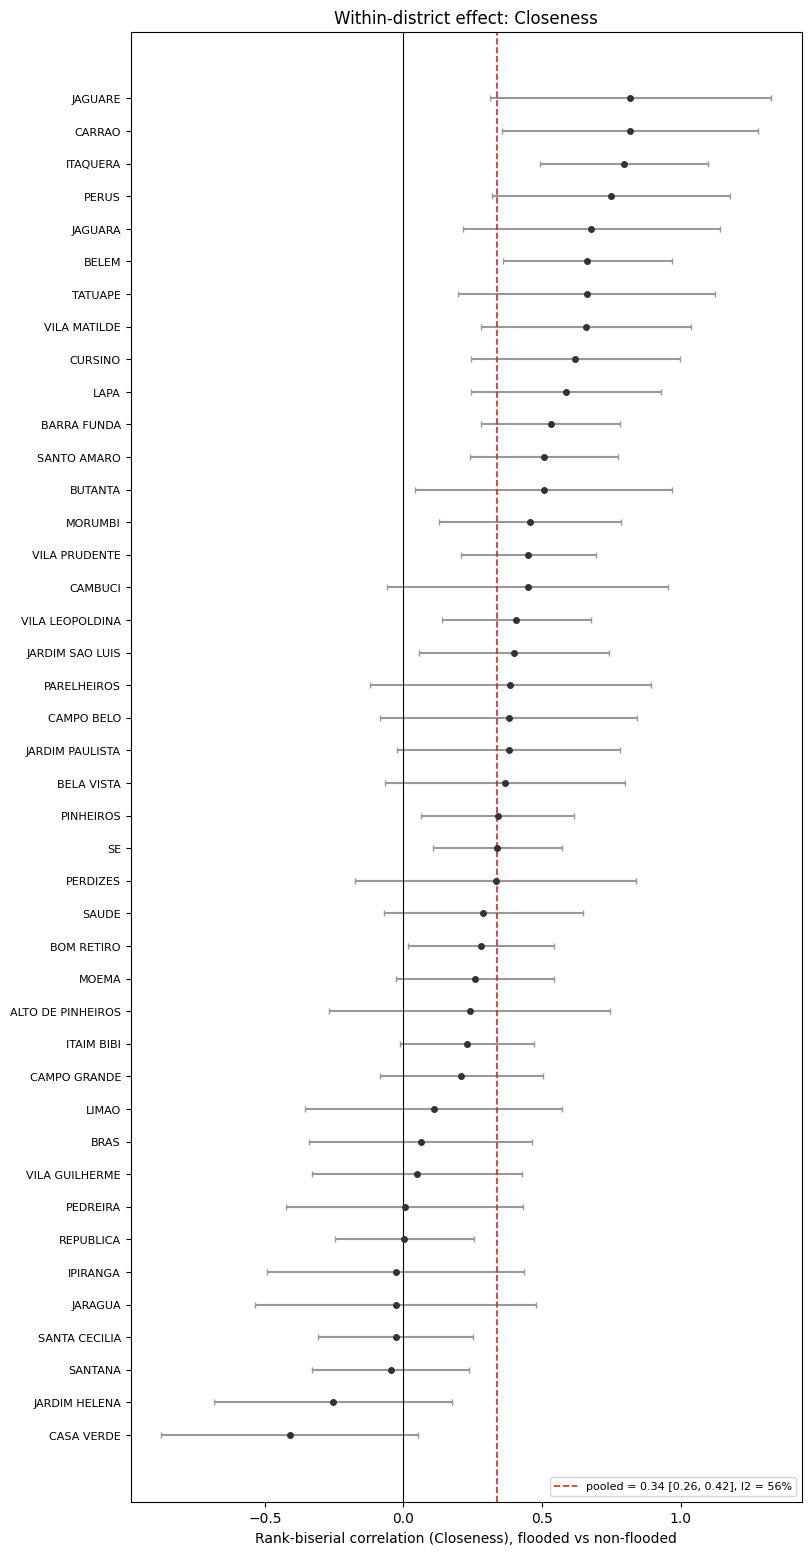

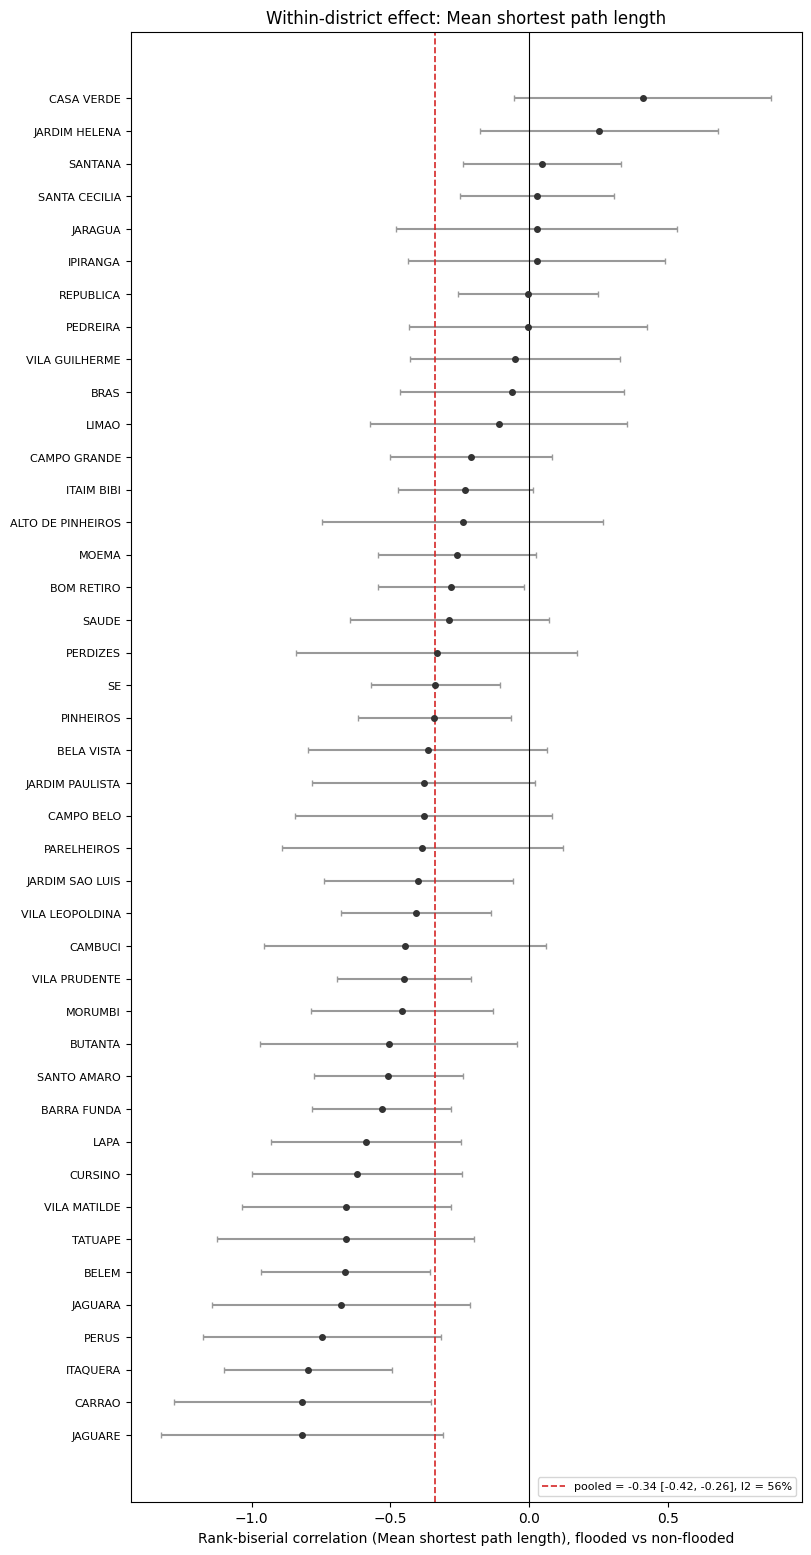

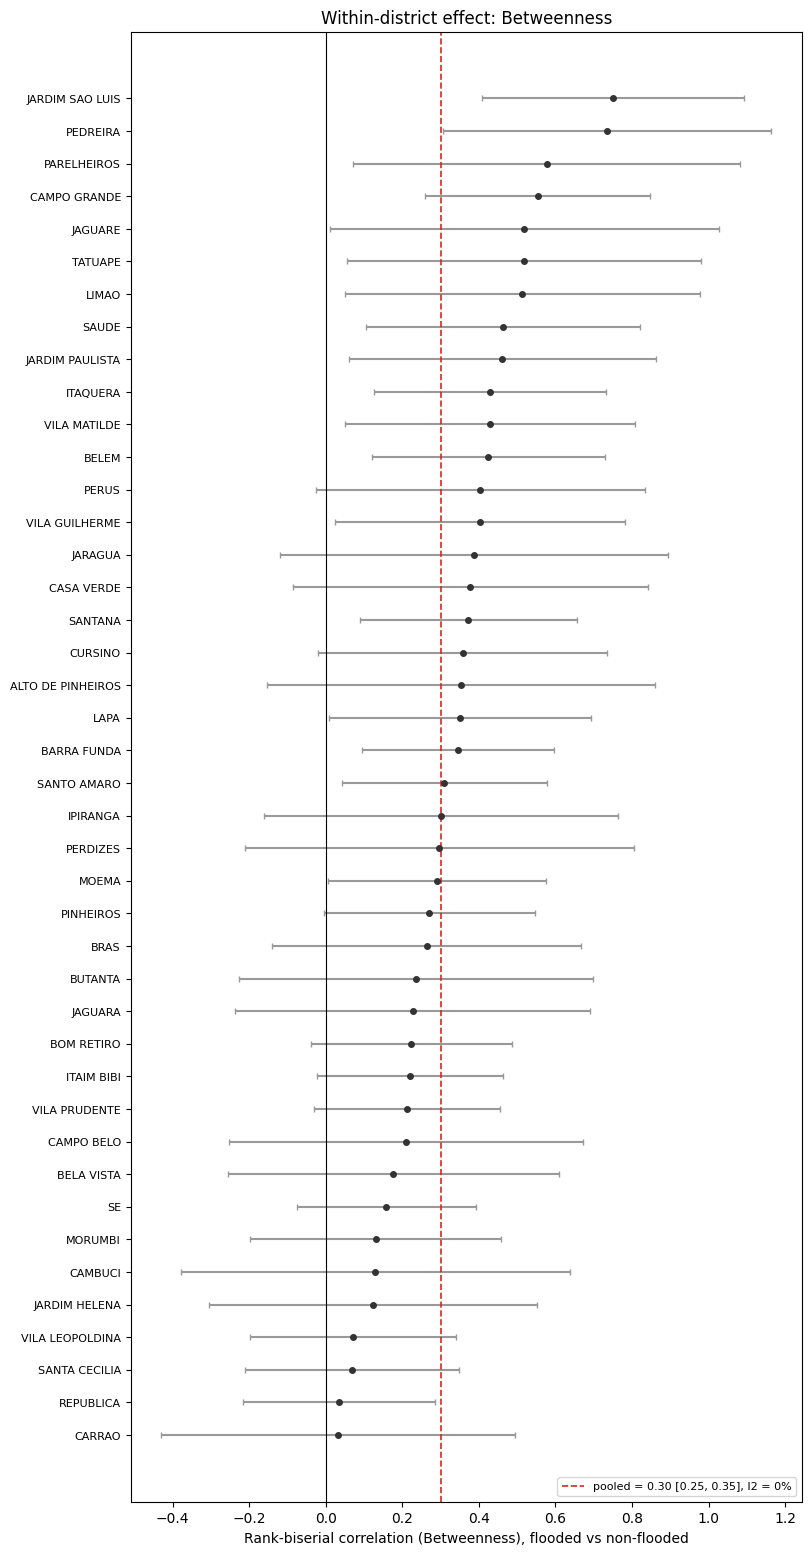

In [10]:
def forest_plot(tests, metric, fname):
    sub = tests[tests["metric"] == metric].sort_values("rank_biserial").reset_index(drop=True)
    pooled, se_p, Q, dfq, tau2, I2 = dersimonian_laird(sub["rank_biserial"].values, sub["se"].values)
    fig, ax = plt.subplots(figsize=(8, 0.32 * len(sub) + 2), layout="constrained")
    ax.errorbar(sub["rank_biserial"], np.arange(len(sub)),
                xerr=[sub["rank_biserial"] - sub["CI_low"], sub["CI_high"] - sub["rank_biserial"]],
                fmt="o", color="#333", ecolor="#999", capsize=2, ms=4)
    ax.axvline(0, color="k", lw=0.8)
    ax.axvline(pooled, color="#d62728", lw=1.2, ls="--",
               label=f"pooled = {pooled:.2f} [{pooled - 1.96 * se_p:.2f}, {pooled + 1.96 * se_p:.2f}], I2 = {I2:.0f}%")
    ax.set_yticks(np.arange(len(sub)))
    ax.set_yticklabels(sub["district"], fontsize=8)
    ax.set_xlabel(f"Rank-biserial correlation ({metric}), flooded vs non-flooded")
    ax.set_title(f"Within-district effect: {metric}")
    ax.legend(loc="lower right", fontsize=8)
    plt.savefig(f"{FIGDIR}/{fname}.png", dpi=200, bbox_inches="tight")
    plt.savefig(f"{FIGDIR}/{fname}.pdf", bbox_inches="tight")
    plt.show()
    return pooled, se_p, I2

def dersimonian_laird(effects, ses):
    """Random-effects pooling (DerSimonian-Laird). Returns pooled, SE, Q, df, tau2, I2%."""
    w = 1.0 / ses ** 2
    fixed = (w * effects).sum() / w.sum()
    Q = (w * (effects - fixed) ** 2).sum()
    dfq = len(effects) - 1
    C = w.sum() - (w ** 2).sum() / w.sum()
    tau2 = max(0.0, (Q - dfq) / C) if C > 0 else 0.0
    w2 = 1.0 / (ses ** 2 + tau2)
    pooled = (w2 * effects).sum() / w2.sum()
    se_p = np.sqrt(1.0 / w2.sum())
    I2 = max(0.0, (Q - dfq) / Q) * 100 if Q > 0 else 0.0
    return pooled, se_p, Q, dfq, tau2, I2

meta_rows = []
for metric in ["Closeness", "Mean shortest path length", "Betweenness"]:
    pooled, se_p, I2 = forest_plot(design2, metric, f"forest_{metric.split()[0].lower()}")
    meta_rows.append({"metric": metric, "pooled_r": pooled, "se": se_p, "I2_pct": I2})

# Pool every metric + sign consistency
for metric in design2["metric"].unique():
    sub = design2[design2["metric"] == metric]
    pooled, se_p, Q, dfq, tau2, I2 = dersimonian_laird(sub["rank_biserial"].values, sub["se"].values)
    n_pos = (sub["rank_biserial"] > 0).sum()
    print(f"{metric:<28} pooled r = {pooled:+.3f} [{pooled - 1.96 * se_p:+.3f}, {pooled + 1.96 * se_p:+.3f}]  "
          f"I2 = {I2:4.0f}%  positive in {n_pos}/{len(sub)} districts")

<ipython-input-1-292be5d469a9>:14: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



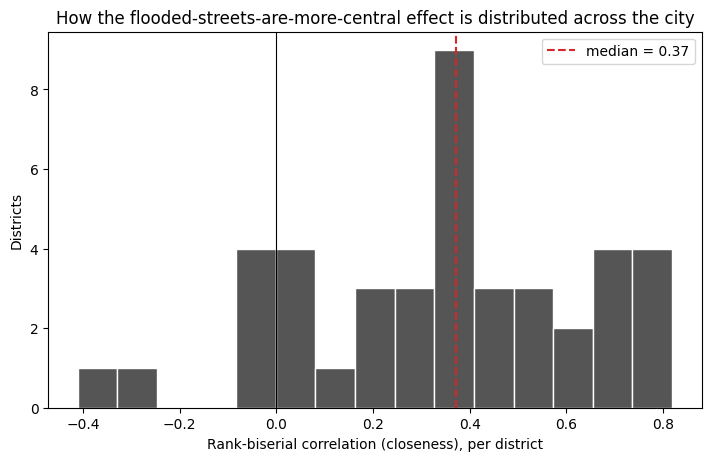

In [11]:
# Distribution of the closeness effect across districts
sub = design2[design2["metric"] == "Closeness"]
fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")
ax.hist(sub["rank_biserial"], bins=15, color="#555", edgecolor="white")
ax.axvline(0, color="k", lw=0.8)
ax.axvline(sub["rank_biserial"].median(), color="#d62728", ls="--",
           label=f"median = {sub['rank_biserial'].median():.2f}")
ax.set_xlabel("Rank-biserial correlation (closeness), per district")
ax.set_ylabel("Districts")
ax.set_title("How the flooded-streets-are-more-central effect is distributed across the city")
ax.legend()
plt.savefig(f"{FIGDIR}/effect_distribution.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/effect_distribution.pdf", bbox_inches="tight")
plt.show()

<ipython-input-1-c9fe3283927a>:18: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



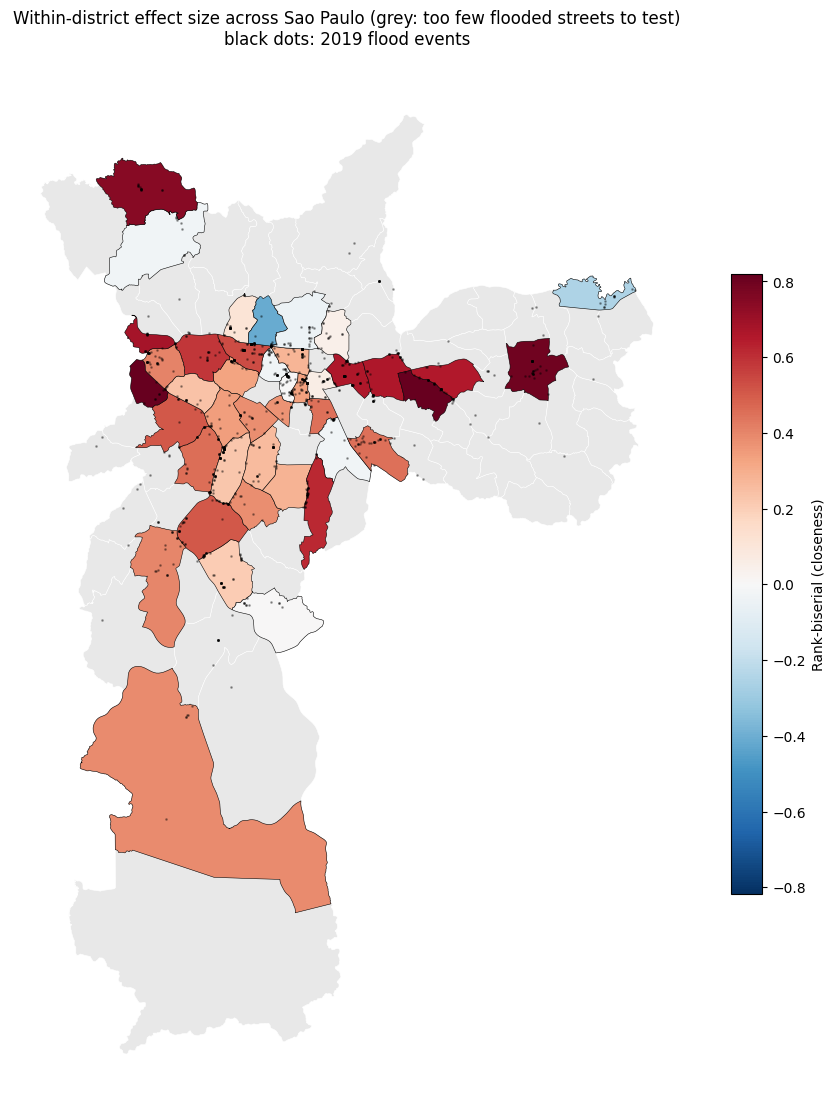

In [12]:
# Choropleth: district polygons colored by the closeness effect size
eff = design2[design2["metric"] == "Closeness"].set_index("district")["rank_biserial"]
plot_gdf = districts_sp.copy()
plot_gdf["effect"] = plot_gdf["NOME"].map(eff)

fig, ax = plt.subplots(figsize=(11, 11), layout="constrained")
plot_gdf.plot(ax=ax, color="#e8e8e8", edgecolor="white", linewidth=0.4)  # untested districts
vmax = np.nanmax(np.abs(plot_gdf["effect"])) or 1
plot_gdf.dropna(subset=["effect"]).plot(column="effect", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                                        ax=ax, edgecolor="black", linewidth=0.4, legend=True,
                                        legend_kwds={"shrink": 0.6, "label": "Rank-biserial (closeness)"})
flood_pts.plot(ax=ax, color="k", markersize=1, alpha=0.3)
ax.set_title("Within-district effect size across Sao Paulo (grey: too few flooded streets to test)\n"
             "black dots: 2019 flood events")
ax.axis("off")
plt.savefig(f"{FIGDIR}/district_effect_map.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/district_effect_map.pdf", bbox_inches="tight")
plt.show()

In [13]:
# Meta-regression sketch: what explains where the effect is strong?
# District mean elevation from ~100 random points per district via OpenTopoData (1 request each).
def district_mean_elevation(poly, n=100, seed=0):
    rng = np.random.default_rng(seed)
    minx, miny, maxx, maxy = poly.bounds
    pts = []
    while len(pts) < n:
        cand = gpd.points_from_xy(rng.uniform(minx, maxx, n), rng.uniform(miny, maxy, n))
        pts += [p for p in cand if poly.contains(p)]
    pts = gpd.GeoSeries(pts[:n], crs=CRS_METRIC).to_crs("EPSG:4326")
    locs = "|".join(f"{p.y:.5f},{p.x:.5f}" for p in pts)
    try:
        rsp = requests.get(f"https://api.opentopodata.org/v1/aster30m?locations={locs}", timeout=30)
        vals = [r["elevation"] for r in rsp.json()["results"] if r["elevation"] is not None]
        return float(np.mean(vals)) if vals else np.nan
    except Exception as err:
        print(f"  elevation lookup failed: {err}")
        return np.nan

elev_fp = f"{RESDIR}/district_elevations.csv"
if os.path.exists(elev_fp):
    delev = pd.read_csv(elev_fp, index_col=0)["mean_elevation"]
else:
    delev = {}
    for name in eff.index:
        poly = districts_sp.loc[districts_sp["NOME"] == name, "geometry"].iloc[0]
        delev[name] = district_mean_elevation(poly)
        time.sleep(1)  # public API rate limit
    delev = pd.Series(delev, name="mean_elevation")
    delev.to_csv(elev_fp)

mr = design2[design2["metric"] == "Closeness"].set_index("district").copy()
mr["mean_elevation"] = delev
mr = mr.join(summary.set_index("district")[["events_matched"]]).dropna()
X_mr = sm.add_constant(pd.DataFrame({
    "log_events": np.log(mr["events_matched"]),
    "log_edges": np.log(mr["n_edges"]),
    "mean_elevation_100m": mr["mean_elevation"] / 100,
}))
print(sm.WLS(mr["rank_biserial"], X_mr, weights=1 / mr["se"] ** 2).fit().summary())

                            WLS Regression Results                            
Dep. Variable:          rank_biserial   R-squared:                       0.028
Model:                            WLS   Adj. R-squared:                 -0.051
Method:                 Least Squares   F-statistic:                    0.3503
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.789
Time:                        20:10:04   Log-Likelihood:                -5.7405
No. Observations:                  41   AIC:                             19.48
Df Residuals:                      37   BIC:                             26.34
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.1657    

## 4. Design 1 vs Design 2: does the modeling choice change the answer?

Same districts, same flood events — the only difference is whether a street's metrics are computed
on the whole central network (Design 1) or on the district's own network (Design 2).

40 district-metric pairs shared by both designs (8 districts)
Spearman correlation of effect sizes across designs: rho = 0.56 (p = 1.7e-04)
Sign agreement: 92%


<ipython-input-1-2b91767b751f>:21: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



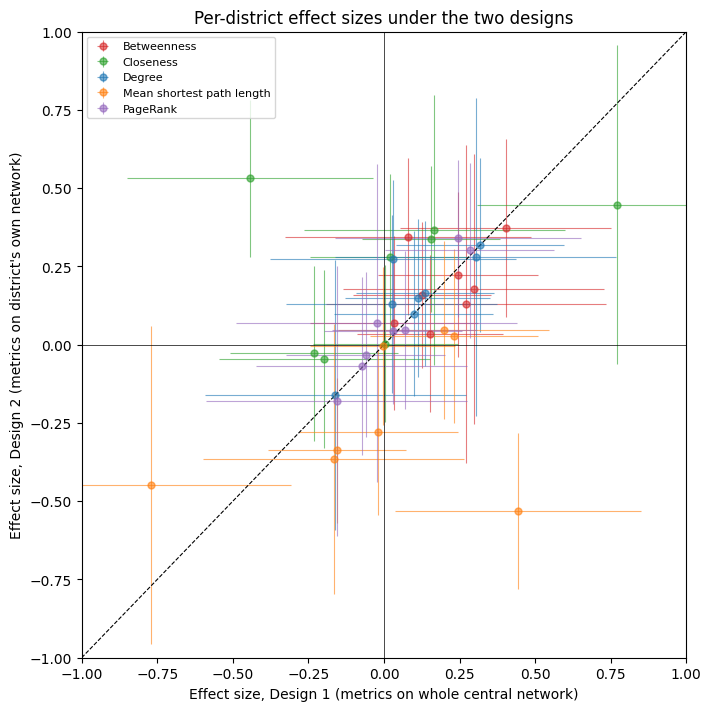

In [14]:
both = design1.merge(design2, on=["district", "metric"], suffixes=("_d1", "_d2"))
both.to_csv(f"{RESDIR}/design_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 7), layout="constrained")
colors = {m: c for m, c in zip(both["metric"].unique(), plt.cm.tab10.colors)}
for m, sub in both.groupby("metric"):
    ax.errorbar(sub["rank_biserial_d1"], sub["rank_biserial_d2"],
                xerr=1.96 * sub["se_d1"], yerr=1.96 * sub["se_d2"],
                fmt="o", ms=5, color=colors[m], ecolor=colors[m], alpha=0.6,
                elinewidth=0.8, capsize=0, label=m)
lims = [-1, 1]
ax.plot(lims, lims, "k--", lw=0.8)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Effect size, Design 1 (metrics on whole central network)")
ax.set_ylabel("Effect size, Design 2 (metrics on district's own network)")
ax.set_title("Per-district effect sizes under the two designs")
ax.legend(fontsize=8)
plt.savefig(f"{FIGDIR}/design_comparison.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/design_comparison.pdf", bbox_inches="tight")
plt.show()

rho, p = spearmanr(both["rank_biserial_d1"], both["rank_biserial_d2"])
agree = (np.sign(both["rank_biserial_d1"]) == np.sign(both["rank_biserial_d2"])).mean()
print(f"{len(both)} district-metric pairs shared by both designs "
      f"({both['district'].nunique()} districts)")
print(f"Spearman correlation of effect sizes across designs: rho = {rho:.2f} (p = {p:.1e})")
print(f"Sign agreement: {agree:.0%}")

## 5. Street-level views of the district decomposition

The sections above use the districts as replication units. Here we exploit what the decomposition
actually gives us: every street now has a **local rank inside its own district's network**.

- **Within-district percentiles**: where does each flooded street sit in the ranking of its own
  district? Pooled over all districts, one curve per metric against the uniform null.
- **Local vs global rank**: for the central districts covered by both networks, is a flooded
  street central *for its district* or central *for the city*? The two rankings only partially
  agree, and they carry different planning implications.
- **Small multiples**: nine districts spanning the effect range, each drawn with its own network
  and its own closeness ranking — the signature (and its failures) made visible.
- **District character**: does terrain relief, street-grid character, or distance to the main
  rivers explain *where* the closeness effect is strong? (Extended meta-regression.)

Closeness    n =  498  median local percentile = 0.75  wilcoxon vs 0.5: p = 1.66e-29
Betweenness  n =  498  median local percentile = 0.70  wilcoxon vs 0.5: p = 4.86e-26
Degree       n =  498  median local percentile = 0.60  wilcoxon vs 0.5: p = 1.02e-12
PageRank     n =  498  median local percentile = 0.58  wilcoxon vs 0.5: p = 5.14e-07


<ipython-input-1-dc1bf5b51d30>:34: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



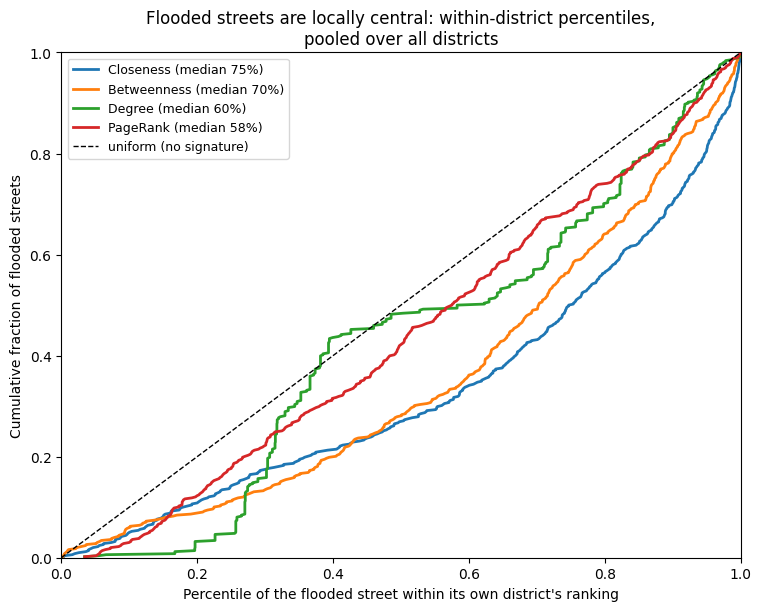

In [15]:
# Where does each flooded street sit in the metric ranking of ITS OWN district?
# Under the null the local percentiles are uniform; the ECDF shows the shift.
from scipy.stats import rankdata, wilcoxon

PCT_METRICS = {"Closeness": "Closeness", "bet": "Betweenness", "Degree": "Degree", "Pagerank": "PageRank"}
pcts = {m: [] for m in PCT_METRICS}
for fp in sorted(glob.glob(f"{RESDIR}/districts/*.csv")):
    df = pd.read_csv(fp)
    fl = df["flood_count"] > 0
    if fl.sum() == 0:
        continue
    for m in PCT_METRICS:
        pct = rankdata(df[m], nan_policy="omit") / df[m].notna().sum()
        pcts[m].extend(pct[fl.values])

fig, ax = plt.subplots(figsize=(7.5, 6), layout="constrained")
colors = dict(zip(PCT_METRICS, plt.cm.tab10.colors))
for m, label in PCT_METRICS.items():
    p = np.sort(np.array(pcts[m]))
    med = np.median(p)
    w_p = wilcoxon(np.array(pcts[m]) - 0.5).pvalue
    print(f"{label:<12} n = {len(p):>4}  median local percentile = {med:.2f}  wilcoxon vs 0.5: p = {w_p:.2e}")
    ax.plot(p, np.arange(1, len(p) + 1) / len(p), lw=2, color=colors[m],
            label=f"{label} (median {med:.0%})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="uniform (no signature)")
ax.set_xlabel("Percentile of the flooded street within its own district's ranking")
ax.set_ylabel("Cumulative fraction of flooded streets")
ax.set_title("Flooded streets are locally central: within-district percentiles,\n"
             "pooled over all districts")
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.savefig(f"{FIGDIR}/local_percentiles.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/local_percentiles.pdf", bbox_inches="tight")
plt.show()

4104 matched streets in 7 districts, 98 flooded
local vs global percentile: spearman rho = 0.53 (p = 4.6e-298)
flooded streets: median local pct = 0.68, median global pct = 0.81
flooded streets locally central but globally peripheral: 10 of 98 (10%)


<ipython-input-1-3a28db8eb371>:52: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



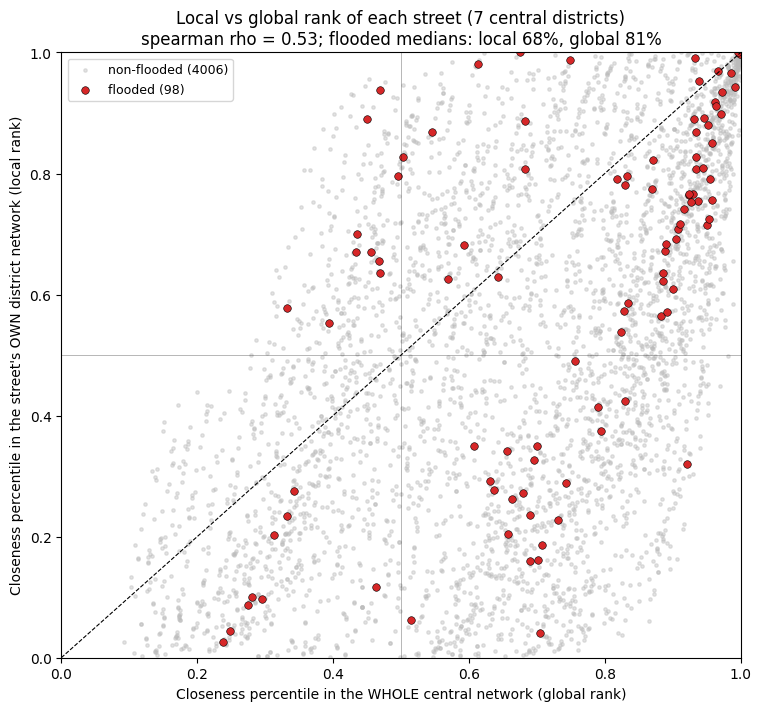

In [16]:
# Local vs global rank: percentile of each street in its own district's closeness ranking
# against its percentile in the WHOLE central network. Streets matched by OSM node ids.
# Restricted to the central districts fully covered by the central network.
from scipy.stats import rankdata

CENTRAL_7 = ["SE", "REPUBLICA", "BELA VISTA", "LIBERDADE", "SANTA CECILIA", "CAMBUCI", "BOM RETIRO"]

cglob = central[["u", "v", "key", "Closeness", "flood_count"]].copy()
cglob["pct_global"] = rankdata(cglob["Closeness"]) / len(cglob)
cglob["ekey"] = [tuple(sorted((u, v))) + (k,) for u, v, k in zip(cglob["u"], cglob["v"], cglob["key"])]
cglob = cglob.set_index("ekey")

lg_rows = []
for name in CENTRAL_7:
    df = pd.read_csv(f"{RESDIR}/districts/{slug(name)}.csv")
    df["pct_local"] = rankdata(df["Closeness"]) / len(df)
    df["ekey"] = [tuple(sorted((u, v))) + (k,) for u, v, k in zip(df["u"], df["v"], df["key"])]
    j = df.join(cglob[["pct_global", "flood_count"]], on="ekey", rsuffix="_c")
    j = j[j["pct_global"].notna()]
    j["district"] = name
    lg_rows.append(j[["district", "pct_local", "pct_global", "flood_count"]])

lg = pd.concat(lg_rows, ignore_index=True)
lg["flooded"] = lg["flood_count"] > 0
fl_lg = lg[lg["flooded"]]
rho_lg, p_lg = spearmanr(lg["pct_local"], lg["pct_global"])
print(f"{len(lg)} matched streets in {lg['district'].nunique()} districts, {len(fl_lg)} flooded")
print(f"local vs global percentile: spearman rho = {rho_lg:.2f} (p = {p_lg:.1e})")
print(f"flooded streets: median local pct = {fl_lg['pct_local'].median():.2f}, "
      f"median global pct = {fl_lg['pct_global'].median():.2f}")
q = ((fl_lg["pct_local"] > 0.5) & (fl_lg["pct_global"] < 0.5)).sum()
print(f"flooded streets locally central but globally peripheral: {q} of {len(fl_lg)} ({q/len(fl_lg):.0%})")

fig, ax = plt.subplots(figsize=(7.5, 7), layout="constrained")
nf_lg = lg[~lg["flooded"]]
ax.scatter(nf_lg["pct_global"], nf_lg["pct_local"], s=6, color="#bbb", alpha=0.4,
           label=f"non-flooded ({len(nf_lg)})")
ax.scatter(fl_lg["pct_global"], fl_lg["pct_local"], s=30, color="#d62728", edgecolor="black",
           linewidth=0.4, label=f"flooded ({len(fl_lg)})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.axhline(0.5, color="k", lw=0.5, alpha=0.4)
ax.axvline(0.5, color="k", lw=0.5, alpha=0.4)
ax.set_xlabel("Closeness percentile in the WHOLE central network (global rank)")
ax.set_ylabel("Closeness percentile in the street's OWN district network (local rank)")
ax.set_title(f"Local vs global rank of each street ({lg['district'].nunique()} central districts)\n"
             f"spearman rho = {rho_lg:.2f}; flooded medians: local {fl_lg['pct_local'].median():.0%}, "
             f"global {fl_lg['pct_global'].median():.0%}")
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.savefig(f"{FIGDIR}/local_vs_global_rank.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/local_vs_global_rank.pdf", bbox_inches="tight")
plt.show()

<ipython-input-1-5e7e27f4e2ad>:43: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



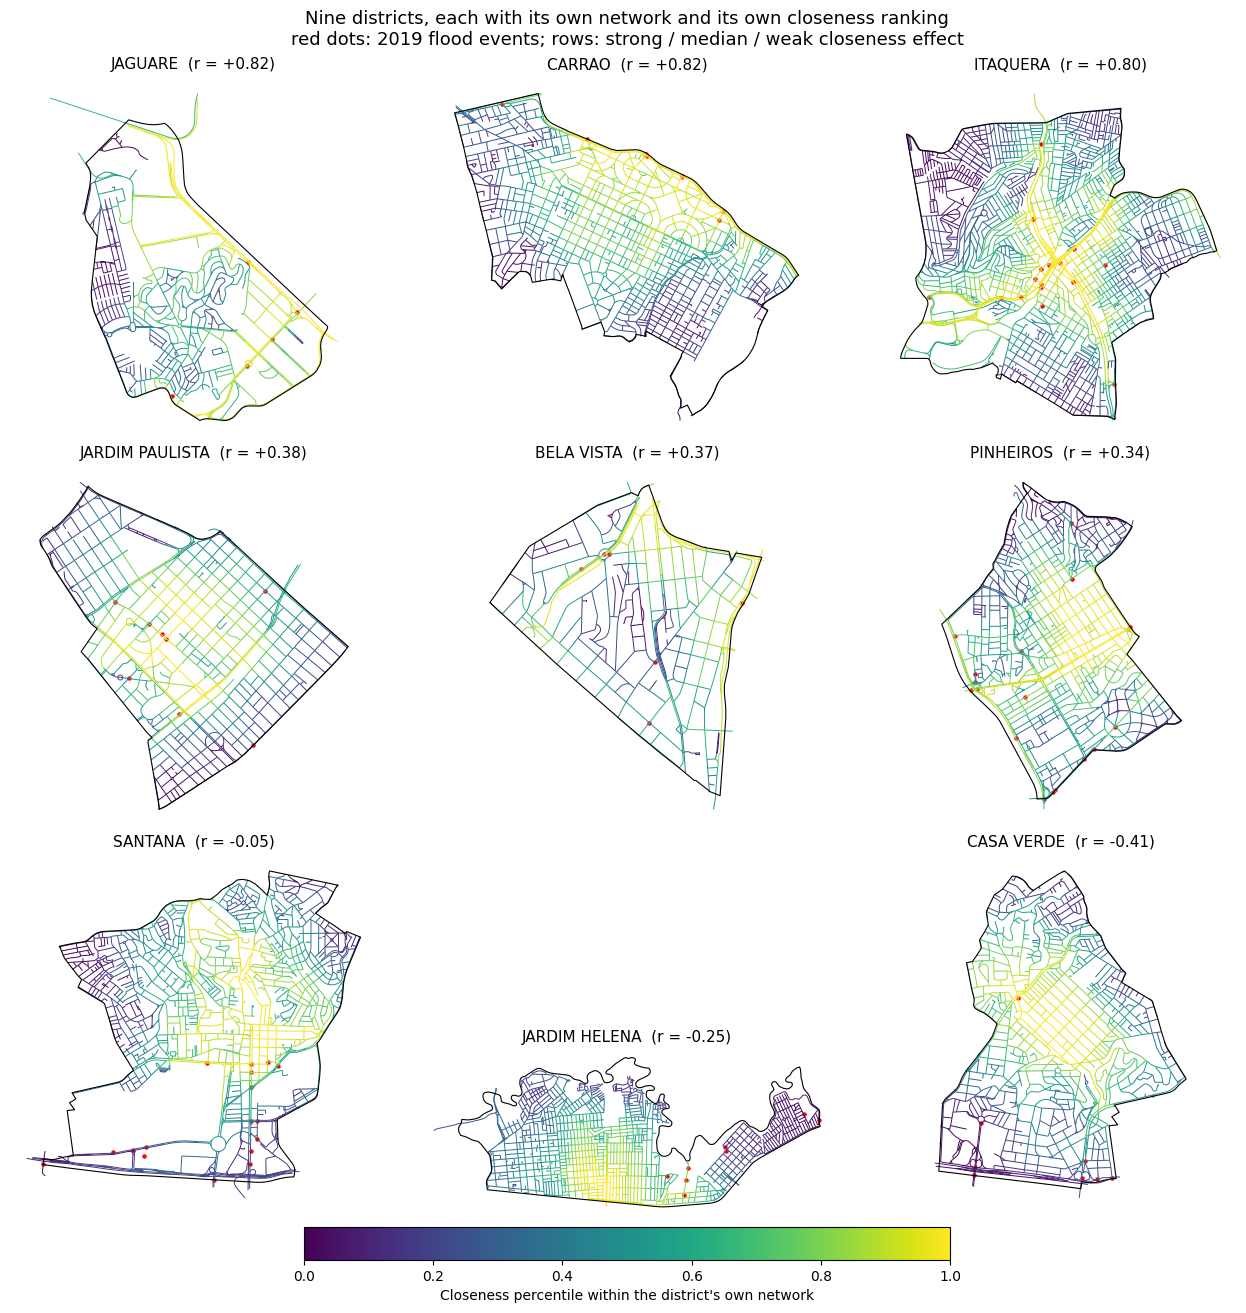

In [17]:
# Small multiples: nine districts spanning the effect range, each drawn with its OWN
# network colored by its OWN closeness percentile (graph rebuilds hit the OSMnx cache)
from scipy.stats import rankdata

clo_sm = design2[design2["metric"] == "Closeness"].sort_values("rank_biserial", ascending=False).reset_index(drop=True)
mid = len(clo_sm) // 2
picks = pd.concat([clo_sm.iloc[:3], clo_sm.iloc[mid - 1:mid + 2], clo_sm.iloc[-3:]])

fig, axes = plt.subplots(3, 3, figsize=(13, 13), layout="constrained")
for ax, (_, prow) in zip(axes.flat, picks.iterrows()):
    name = prow["district"]
    poly = districts_sp.loc[districts_sp["NOME"] == name, "geometry"].iloc[0]
    poly_wgs = gpd.GeoSeries([poly.buffer(1000)], crs=CRS_METRIC).to_crs("EPSG:4326").iloc[0]
    Gd = ox.convert.to_undirected(ox.graph_from_polygon(poly_wgs, network_type="drive"))
    Gd = Gd.subgraph(max(nx.connected_components(Gd), key=len)).copy()
    _, dedges = ox.graph_to_gdfs(Gd)
    dedges = dedges.reset_index().to_crs(CRS_METRIC)
    mids = dedges.geometry.interpolate(0.5, normalized=True)
    dedges = dedges[mids.within(poly).values].copy()

    chk = pd.read_csv(f"{RESDIR}/districts/{slug(name)}.csv")
    chk["pct_local"] = rankdata(chk["Closeness"]) / len(chk)
    chk["ekey"] = [tuple(sorted((u, v))) + (k,) for u, v, k in zip(chk["u"], chk["v"], chk["key"])]
    dedges["ekey"] = [tuple(sorted((u, v))) + (k,) for u, v, k in zip(dedges["u"], dedges["v"], dedges["key"])]
    dedges = dedges.merge(chk[["ekey", "pct_local"]], on="ekey", how="inner")

    dedges.sort_values("pct_local").plot(ax=ax, column="pct_local", cmap="viridis",
                                         linewidth=0.7, vmin=0, vmax=1)
    flood_pts[flood_pts.within(poly)].plot(ax=ax, color="red", markersize=14, marker="o",
                                           edgecolor="white", linewidth=0.5)
    gpd.GeoSeries([poly.boundary], crs=CRS_METRIC).plot(ax=ax, color="black", linewidth=0.8)
    ax.set_title(f"{name}  (r = {prow['rank_biserial']:+.2f})", fontsize=11)
    ax.set_aspect("equal")
    ax.axis("off")

sm_cb = plt.cm.ScalarMappable(cmap="viridis", norm=matplotlib.colors.Normalize(0, 1))
cbar = fig.colorbar(sm_cb, ax=axes, shrink=0.5, location="bottom", pad=0.01)
cbar.set_label("Closeness percentile within the district's own network")
fig.suptitle("Nine districts, each with its own network and its own closeness ranking\n"
             "red dots: 2019 flood events; rows: strong / median / weak closeness effect", fontsize=13)
plt.savefig(f"{FIGDIR}/district_small_multiples.png", dpi=200, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/district_small_multiples.pdf", bbox_inches="tight")
plt.show()

In [18]:
# District character: does anything explain WHERE the closeness effect is strong?
# Terrain relief (elevation std), street-grid character (orientation entropy, circuity),
# and distance to the Tiete/Pinheiros rivers, checkpointed per district.
clo_d = design2[design2["metric"] == "Closeness"].set_index("district")
CHAR_FP = f"{RESDIR}/district_character.csv"
done = pd.read_csv(CHAR_FP)["district"].tolist() if os.path.exists(CHAR_FP) else []
need = [d for d in clo_d.index if d not in done]

if need:
    # rivers: Tiete + Pinheiros geometries from OSM (cached Overpass query)
    hull = gpd.GeoSeries([districts_sp.geometry.unary_union.convex_hull],
                         crs=CRS_METRIC).to_crs("EPSG:4326").iloc[0]
    rivers = ox.features_from_polygon(hull, {"waterway": "river"})
    rivers = rivers[rivers["name"].fillna("").str.contains("Tiet|Pinheiros", case=False)]
    river_geom = gpd.GeoSeries([rivers.geometry.unary_union], crs="EPSG:4326").to_crs(CRS_METRIC).iloc[0]

    def elevation_sample(poly, n=100, seed=0):
        rng = np.random.default_rng(seed)
        minx, miny, maxx, maxy = poly.bounds
        pts = []
        while len(pts) < n:
            cand = gpd.points_from_xy(rng.uniform(minx, maxx, n), rng.uniform(miny, maxy, n))
            pts += [p for p in cand if poly.contains(p)]
        pts = gpd.GeoSeries(pts[:n], crs=CRS_METRIC).to_crs("EPSG:4326")
        locs = "|".join(f"{p.y:.5f},{p.x:.5f}" for p in pts)
        rsp = requests.get(f"https://api.opentopodata.org/v1/aster30m?locations={locs}", timeout=30)
        vals = [r["elevation"] for r in rsp.json()["results"] if r["elevation"] is not None]
        return (float(np.mean(vals)), float(np.std(vals))) if vals else (np.nan, np.nan)

    header_needed = not os.path.exists(CHAR_FP)
    for name in need:
        poly = districts_sp.loc[districts_sp["NOME"] == name, "geometry"].iloc[0]
        try:
            elev_mean, elev_std = elevation_sample(poly)
            time.sleep(1)  # public API rate limit
            poly_wgs = gpd.GeoSeries([poly.buffer(1000)], crs=CRS_METRIC).to_crs("EPSG:4326").iloc[0]
            Gd = ox.convert.to_undirected(ox.graph_from_polygon(poly_wgs, network_type="drive"))
            Gd = Gd.subgraph(max(nx.connected_components(Gd), key=len)).copy()
            entropy = ox.bearing.orientation_entropy(ox.bearing.add_edge_bearings(Gd))
            circuity = ox.stats.circuity_avg(Gd)
            row = {"district": name, "elev_mean": elev_mean, "elev_std": elev_std,
                   "orientation_entropy": entropy, "circuity": circuity,
                   "dist_river_km": poly.centroid.distance(river_geom) / 1000}
            pd.DataFrame([row]).to_csv(CHAR_FP, mode="a", index=False, header=header_needed)
            header_needed = False
            print(f"{name:<20} done")
        except Exception as err:
            print(f"{name:<20} FAILED: {err}")

char = pd.read_csv(CHAR_FP).drop_duplicates("district").set_index("district")
mr_ext = clo_d.join(char).dropna()

def z(s):
    return (s - s.mean()) / s.std()

X_ext = sm.add_constant(pd.DataFrame({
    "elev_std": z(mr_ext["elev_std"]),
    "elev_mean": z(mr_ext["elev_mean"]),
    "orientation_entropy": z(mr_ext["orientation_entropy"]),
    "circuity": z(mr_ext["circuity"]),
    "dist_river": z(mr_ext["dist_river_km"]),
    "log_edges": z(np.log(mr_ext["n_edges"])),
}))
res_ext = sm.WLS(mr_ext["rank_biserial"], X_ext, weights=1 / mr_ext["se"] ** 2).fit()
pd.DataFrame({"coef": res_ext.params, "se": res_ext.bse, "p": res_ext.pvalues,
              "CI_low": res_ext.conf_int()[0], "CI_high": res_ext.conf_int()[1]}
             ).to_csv(f"{RESDIR}/meta_regression_extended.csv")
print(res_ext.summary())

                            WLS Regression Results                            
Dep. Variable:          rank_biserial   R-squared:                       0.024
Model:                            WLS   Adj. R-squared:                 -0.144
Method:                 Least Squares   F-statistic:                    0.1421
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.989
Time:                        20:10:52   Log-Likelihood:                -5.2126
No. Observations:                  42   AIC:                             24.43
Df Residuals:                      35   BIC:                             36.59
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.3432    

## Outputs

- `results/design1_district_tests.csv`, `results/design2_district_tests.csv`,
  `results/design2_district_summary.csv`, `results/design_comparison.csv`,
  `results/buffer_sensitivity.csv`, `results/district_elevations.csv`,
  `results/district_character.csv`, `results/meta_regression_extended.csv`
- `results/districts/*.csv` — per-district edge tables (metrics + flood counts)
- `figures/forest_closeness`, `figures/forest_mean`, `figures/forest_betweenness`,
  `figures/effect_distribution`, `figures/district_effect_map`, `figures/design_comparison`,
  `figures/local_percentiles`, `figures/local_vs_global_rank`,
  `figures/district_small_multiples` (PNG + PDF each)